In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
import re

# Load the data
df = pd.read_csv('CA_DMV_CollisionsDataset.csv')

# Function to convert Excel date to datetime
def excel_date_to_datetime(excel_date):
    return pd.to_datetime('1899-12-30') + pd.Timedelta(days=int(excel_date), seconds=int((excel_date % 1) * 86400))

# Convert Date and Time to datetime
def convert_to_datetime(date, time):
    try:
        # Try the original format
        return pd.to_datetime(f"{date} {time}", format='%m/%d/%y %I:%M %p')
    except ValueError:
        try:
            # If that fails, try Excel date format
            return excel_date_to_datetime(float(date) + float(time))
        except ValueError:
            # If both fail, return NaT (Not a Time)
            return pd.NaT

# Apply the conversion
df['DateTime'] = df.apply(lambda row: convert_to_datetime(row['Date'], row['Time']), axis=1)

# Remove rows where DateTime conversion failed
df = df.dropna(subset=['DateTime'])

# Create new features
df['IsWeekend'] = df['DateTime'].dt.dayofweek.isin([5, 6]).astype(int)

# Define time periods
def get_time_period(hour):
    if 5 <= hour < 9:
        return 'morning peak'
    elif 11 <= hour < 14:
        return 'midday'
    elif 16 <= hour < 19:
        return 'evening peak'
    else:
        return 'off peak'

df['TimePeriod'] = df['DateTime'].dt.hour.apply(get_time_period)

# Process Damaged Area with error handling
def process_damaged_area(damage_str):
    try:
        if pd.isna(damage_str):
            return [0] * 20
        damage_list = [int(x.strip()) for x in str(damage_str).split(',') if x.strip().isdigit()]
        return [1 if i in damage_list else 0 for i in range(20)]
    except ValueError:
        print(f"Error processing damaged area: {damage_str}")
        return [0] * 20

damage_columns = [f'Damage_{i}' for i in range(20)]
df[damage_columns] = df['Damaged Area'].apply(process_damaged_area).tolist()

# Function to clean and lowercase strings
def clean_and_lowercase(x):
    if isinstance(x, str):
        return x.lower().strip()
    return x

# Function to split compound values
def split_compound_values(x):
    if isinstance(x, str):
        return [item.strip() for item in x.split(',')]
    return x

# Apply clean_and_lowercase and split_compound_values to all object columns
object_columns = df.select_dtypes(include=['object']).columns
for col in object_columns:
    df[col] = df[col].apply(clean_and_lowercase)
    df[col] = df[col].apply(split_compound_values)

# Handle multi-value fields
multi_value_fields = ['Weather', 'Mov Proceed Col Veh 1', 'Mov Proceed Col Veh 2', 'Lighting', 'Vehicle 1 Status', 'Vehicle 2 Status', 'Roadway Surface', 'Roadway Condition']

# Handle Describe Vehicle Damage separately
if 'Describe Veh Damage' in df.columns:
    describe_damage_dummies = pd.get_dummies(df['Describe Veh Damage'].apply(lambda x: ','.join(x) if isinstance(x, list) else x), prefix='Describe Veh Damage', prefix_sep='_')
    if 'Describe Veh Damage_none' in describe_damage_dummies.columns:
        describe_damage_dummies.drop('Describe Veh Damage_none', axis=1, inplace=True)
    df = pd.concat([df, describe_damage_dummies], axis=1)

# Handle 'Collision Type' separately
if 'Collision Type' in df.columns:
    collison_type_dummies = pd.get_dummies(df['Collision Type'].apply(lambda x: ','.join(x) if isinstance(x, list) else x), prefix='Collision Type', prefix_sep='_')
    if 'Collision Type_unknown' in collison_type_dummies.columns:
        collison_type_dummies.drop('Collision Type_unknown', axis=1, inplace=True)
    df = pd.concat([df, collison_type_dummies], axis=1)

# Creating dummy variables for other multi-value fields and drop the first column
for field in multi_value_fields:
    if field == 'Describe Veh Damage':
        continue
    if field in df.columns:
        # Flatten lists into strings for dummy creation
        df[field] = df[field].apply(lambda x: ','.join(x) if isinstance(x, list) else x)
        # Create dummy variables and drop the first column
        dummies = pd.get_dummies(df[field], prefix=field, prefix_sep='_', dummy_na=False)
        dummies = dummies.iloc[:, 1:]  # Drop the first column
        df = pd.concat([df, dummies], axis=1)
    else:
        print(f"Column '{field}' not found in the DataFrame.")

# Drop the original multi-value fields
df = df.drop(columns=[col for col in multi_value_fields if col in df.columns])


In [3]:
# Select features for encoding
categorical_features = ['Company', 'City', 'Mode', 'Vehicle type', 'Location', 'IsWeekend', 'TimePeriod', 'Fault'] + damage_columns

# Add the new binary columns to categorical_features
for field in multi_value_fields:
    categorical_features.extend([col for col in df.columns if col.startswith(f'{field}_')])

# Ensure Describe Vehicle Damage columns are included
categorical_features.extend([col for col in df.columns if col.startswith('Describe Veh Damage_')])

# Ensure Describe Vehicle Damage columns are included
categorical_features.extend([col for col in df.columns if col.startswith('Collision Type_')])

# Ensure all categorical features are strings
for feature in categorical_features:
    df[feature] = df[feature].astype(str)

# One-hot encoding for categorical variables
encoder = OneHotEncoder(drop='first', handle_unknown='ignore')
encoded_features = encoder.fit_transform(df[categorical_features])

# Use the feature names that the encoder was fitted on
encoded_feature_names = encoder.get_feature_names_out()

# Create a new dataframe with encoded features
encoded_df = pd.DataFrame(encoded_features.toarray(), columns=encoded_feature_names, index=df.index)

# Select numerical features
numerical_features = ['Vehicles Involved', 'Number of injuries']

# Combine encoded categorical and numerical features
final_df = pd.concat([encoded_df, df[numerical_features]], axis=1)

# Add Date and Time columns
final_df['Date'] = df['Date']
final_df['Time'] = df['Time']

# Handle missing values
imputer = SimpleImputer(strategy='mean')
numerical_columns = final_df.select_dtypes(include=[np.number]).columns
final_df[numerical_columns] = imputer.fit_transform(final_df[numerical_columns])

# Save processed data
final_df.to_csv('pre_collision_data.csv', index=False)
print("\nDataFrame shape before scaling:", final_df.shape)



DataFrame shape before scaling: (641, 152)


In [4]:
def categorize_severity(row):
    injuries = row['Number of injuries']
    damage_minor = row.get('Describe Veh Damage_minor_True', 0)
    damage_moderate = row.get('Describe Veh Damage_moderate_True', 0)
    damage_major = row.get('Describe Veh Damage_major_True', 0)

    # Categorize severity
    if injuries == 0 and damage_minor == 0 and damage_moderate == 0 and damage_major == 0:
        return 0  # No injuries and no vehicle damage
    elif (injuries == 0 and damage_minor == 1) or (injuries == 1 and damage_minor == 0):
        return 1  # No injuries and minor vehicle damage OR 1 injury and no vehicle damage
    elif (injuries == 1 and damage_minor == 1) or (injuries == 2 and (damage_minor == 0 or damage_minor == 1)) or (injuries == 0 and damage_moderate == 1):
        return 2  # 1 injury and minor vehicle damage OR 2 injuries and no or minor vehicle damage OR no injuries and moderate vehicle damage
    elif injuries >= 3 or damage_major == 1 or (injuries > 0 and damage_major == 1):
        return 3  # 3 or more injuries, significant vehicle damage, or any combination of injuries and significant vehicle damage
    else:
        return 'Moderate Collision'  # Default to moderate if not classified as no impact, minor, or severe

# Apply the function to create the new target variable
final_df['crash_severity'] = final_df.apply(categorize_severity, axis=1)

# Create a dictionary for readability
severity_labels = {
    0: 'NONE',
    1: 'MINOR',
    2: 'MODERATE',
    3: 'SEVERE'
}

# Apply labels for better interpretability
final_df['crash_severity_label'] = final_df['crash_severity'].map(severity_labels)

# Save the processed data
final_df.to_csv('processed_collision_data.csv', index=False)


/var/folders/76/53hj2t212512j_3_p2ptnwcw0000gn/T/ipykernel_36447/2501407380.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final_df['crash_severity'] = final_df.apply(categorize_severity, axis=1)
/var/folders/76/53hj2t212512j_3_p2ptnwcw0000gn/T/ipykernel_36447/2501407380.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  final_df['crash_severity_label'] = final_df['crash_severity'].map(severity_labels)


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Identify binary and numerical columns
binary_columns = final_df.columns[final_df.isin([0, 1]).all()].tolist()
numerical_features = ['Vehicles Involved', 'Number of injuries']

# Create a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features)
    ],
    remainder='passthrough'  # This will leave the binary columns untouched
)

# Fit and transform the data
scaled_data = preprocessor.fit_transform(final_df.drop(['Date', 'Time'], axis=1))

# Get the feature names after transformation
scaled_feature_names = (numerical_features + 
                        [col for col in final_df.columns if col not in numerical_features + ['Date', 'Time']])

# Convert back to DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=scaled_feature_names, index=final_df.index)

# Add back Date and Time columns
scaled_df['Date'] = final_df['Date']
scaled_df['Time'] = final_df['Time']

print("\nDataFrame after scaling:")
print(scaled_df.head())
print("\nDataFrame shape after scaling:", scaled_df.shape)

# Save processed data
scaled_df.to_csv('processed_collision_data.csv', index=False)

print("\nProcessed data has been saved to 'processed_collision_data.csv'")


DataFrame after scaling:
  Vehicles Involved Number of injuries Company_['aiargo']  \
0          0.297525          -0.295876                0.0   
1          0.297525           2.534815                0.0   
2          0.297525          -0.295876                0.0   
3          0.297525          -0.295876                0.0   
4          0.297525          -0.295876                0.0   

  Company_['aimotive'] Company_['apollo'] Company_['apple']  \
0                  0.0                0.0               0.0   
1                  0.0                0.0               0.0   
2                  0.0                0.0               0.0   
3                  0.0                0.0               0.0   
4                  0.0                0.0               0.0   

  Company_['aurora'] Company_['b'] Company_['beep'] Company_['c']  ...  \
0                0.0           1.0              0.0           0.0  ...   
1                0.0           0.0              0.0           1.0  ...   
2     

In [6]:
#Data Augmentation

In [7]:
print(scaled_df['crash_severity'].value_counts())
print(scaled_df['crash_severity'].dtype)

# Investigate cases where Damage_0_1 is 1 and crash severity is non-zero
discrepancy_cases = scaled_df[(scaled_df['Damage_0_1'] == 1) & (scaled_df['crash_severity'] != 0)]
print(discrepancy_cases[['Damage_0_1', 'crash_severity', 'crash_severity_label']])

# Count the number of such cases
num_discrepancy_cases = len(discrepancy_cases)
print(f"Number of discrepancy cases: {num_discrepancy_cases}")


crash_severity
1    458
2    126
0     44
3     13
Name: count, dtype: int64
object
    Damage_0_1 crash_severity crash_severity_label
31         1.0              1                MINOR
85         1.0              1                MINOR
91         1.0              1                MINOR
116        1.0              1                MINOR
126        1.0              1                MINOR
143        1.0              1                MINOR
144        1.0              1                MINOR
175        1.0              1                MINOR
242        1.0              1                MINOR
336        1.0              1                MINOR
400        1.0              1                MINOR
423        1.0              2             MODERATE
451        1.0              1                MINOR
Number of discrepancy cases: 13


In [ ]:
#Start here for both observations, the following keeps Damage_0 in dataset

In [ ]:
#New observation

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from collections import Counter

# Load the processed data
final_df = pd.read_csv('processed_collision_data.csv')

# Filter out instances with crash severity level 0 (NONE)
filtered_df = final_df[final_df['crash_severity'] != 0]

# Identify binary and numerical columns
binary_columns = filtered_df.columns[filtered_df.isin([0, 1]).all()].tolist()
numerical_features = ['Vehicles Involved', 'Number of injuries']

# Create a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features)
    ],
    remainder='passthrough'  # This will leave the binary columns untouched
)

# Fit and transform the data
scaled_data = preprocessor.fit_transform(filtered_df.drop(['Date', 'Time'], axis=1))

# Get the feature names after transformation
scaled_feature_names = (numerical_features + 
                        [col for col in filtered_df.columns if col not in numerical_features + ['Date', 'Time']])

# Convert back to DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=scaled_feature_names, index=filtered_df.index)

# Add back Date and Time columns
scaled_df['Date'] = filtered_df['Date']
scaled_df['Time'] = filtered_df['Time']

# Save processed data
scaled_df.to_csv('Scaled_severity_filtered.csv', index=False)

print(f"dataframe shape: {scaled_df.shape}")
print("\nProcessed data has been saved to 'Scaled_severity_filtered.csv'")

# Ensure crash_severity is in the dataframe and convert to integers
if 'crash_severity' in scaled_df.columns:
    scaled_df['crash_severity'] = pd.to_numeric(scaled_df['crash_severity'], errors='coerce')
    scaled_df['crash_severity'] = scaled_df['crash_severity'].astype(int)
else:
    print("Error: 'crash_severity' column not found in the dataframe.")
    exit()

# Remove Describe Vehicle Damage columns and Number of injuries from the feature set
features_to_exclude = [col for col in scaled_df.columns if col.startswith('Describe Vehicle Damage_')]
features_to_exclude.append('Number of injuries')

# Separate features and target, excluding specified columns
X = scaled_df.drop(['Date', 'Time', 'crash_severity_label', 'crash_severity'] + features_to_exclude, axis=1)
y = scaled_df['crash_severity']

In [ ]:
# Split the data into training and testing sets using stratified sampling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Check the distribution of classes before SMOTE
print("Class distribution before SMOTE:")
print(Counter(y_train))

# Ensure y_train is of integer type
y_train = y_train.astype(int)

# Apply SMOTE to balance only classes 0 and 3 to the target size
smote = SMOTE(sampling_strategy={2: 210, 3: 41}, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Check the distribution of classes after SMOTE
print("\nClass distribution after SMOTE:")
print(Counter(y_train_smote))

# Proceed with your model training and evaluation as before
# For example:
# Define and fit RFE with Random Forest
rf_model_rfe = RandomForestClassifier(random_state=42)
rfe_rf = RFE(estimator=rf_model_rfe, n_features_to_select=20)
rfe_rf = rfe_rf.fit(X_train_smote, y_train_smote)
selected_features_rf = [f for f, r in zip(X_train_smote.columns, rfe_rf.ranking_) if r == 1]

# Define and fit RFE with Logistic Regression
logistic_model_rfe = LogisticRegression(random_state=42, max_iter=10000)
rfe_logistic = RFE(estimator=logistic_model_rfe, n_features_to_select=20)
rfe_logistic = rfe_logistic.fit(X_train_smote, y_train_smote)
selected_features_logistic = [f for f, r in zip(X_train_smote.columns, rfe_logistic.ranking_) if r == 1]

# Train and evaluate Random Forest model using features selected by RFE with Random Forest
rf_model_rf_features = RandomForestClassifier(random_state=42)
X_train_selected_rf = X_train_smote[selected_features_rf]
X_test_selected_rf = X_test[selected_features_rf]
rf_model_rf_features.fit(X_train_selected_rf, y_train_smote)
y_pred_rf = rf_model_rf_features.predict(X_test_selected_rf)
y_score_rf = rf_model_rf_features.predict_proba(X_test_selected_rf)

print("Confusion Matrix for RFE with Random Forest:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report for RFE with Random Forest:")
print(classification_report(y_test, y_pred_rf))

# Generate the confusion matrix for RFE with Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=rf_model_rf_features.classes_, yticklabels=rf_model_rf_features.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap for RFE with Random Forest')
plt.show()

# Train and evaluate Random Forest model using features selected by RFE with Logistic Regression
rf_model_log_features = RandomForestClassifier(random_state=42)
X_train_selected_log = X_train_smote[selected_features_logistic]
X_test_selected_log = X_test[selected_features_logistic]
rf_model_log_features.fit(X_train_selected_log, y_train_smote)
y_pred_log = rf_model_log_features.predict(X_test_selected_log)
y_score_log = rf_model_log_features.predict_proba(X_test_selected_log)

print("Confusion Matrix for RFE with Logistic Regression:")
print(confusion_matrix(y_test, y_pred_log))
print("\nClassification Report for RFE with Logistic Regression:")
print(classification_report(y_test, y_pred_log))

# Generate the confusion matrix for RFE with Logistic Regression
cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(10, 7))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', xticklabels=rf_model_log_features.classes_, yticklabels=rf_model_log_features.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap for RFE with Logistic Regression')
plt.show()

# Plot the ROC curve for both
def plot_roc_curve(y_test, y_score, n_classes, title):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    plt.figure(figsize=(12, 8))
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red'])
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))
    plt.plot(fpr["micro"], tpr["micro"], color='deeppink', linestyle=':', linewidth=4, label='micro-average ROC curve (area = {0:0.2f})'.format(roc_auc["micro"]))
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()

# Binarize the output
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]

plot_roc_curve(y_test_bin, y_score_rf, n_classes, 'Receiver Operating Characteristic (ROC) Curve for RFE with Random Forest')
plot_roc_curve(y_test_bin, y_score_log, n_classes, 'Receiver Operating Characteristic (ROC) Curve for RFE with Logistic Regression')

# Extract feature importances for both models
importances_rf = rf_model_rf_features.feature_importances_
indices_rf = np.argsort(importances_rf)[::-1]

importances_log = rf_model_log_features.feature_importances_
indices_log = np.argsort(importances_log)[::-1]

In [ ]:
# Plot the feature importances for Random Forest-selected features
plt.figure(figsize=(12, 8))
plt.title("Feature Importances (RFE with Random Forest)", fontsize = 25)
plt.bar(range(X_train_selected_rf.shape[1]), importances_rf[indices_rf], align="center")
plt.xticks(range(X_train_selected_rf.shape[1]), [selected_features_rf[i] for i in indices_rf], rotation=90, fontsize = 16)
plt.xlim([-1, X_train_selected_rf.shape[1]])
plt.show()

# Plot the feature importances for Logistic Regression-selected features
plt.figure(figsize=(12, 8))
plt.title("Feature Importances (RFE with Logistic Regression)", fontsize = 25)
plt.bar(range(X_train_selected_log.shape[1]), importances_log[indices_log], align="center")
plt.xticks(range(X_train_selected_log.shape[1]), [selected_features_logistic[i] for i in indices_log], rotation=90, fontsize = 16)
plt.xlim([-1, X_train_selected_log.shape[1]])
plt.show()


DataFrame after scaling:
  Vehicles Involved Number of injuries Company_['aiargo']  \
0          0.278513          -0.307579                0.0   
1          0.278513           2.433088                0.0   
2          0.278513          -0.307579                0.0   
3          0.278513          -0.307579                0.0   
4          0.278513          -0.307579                0.0   

  Company_['aimotive'] Company_['apollo'] Company_['apple']  \
0                  0.0                0.0               0.0   
1                  0.0                0.0               0.0   
2                  0.0                0.0               0.0   
3                  0.0                0.0               0.0   
4                  0.0                0.0               0.0   

  Company_['aurora'] Company_['b'] Company_['beep'] Company_['c']  ...  \
0                0.0           1.0              0.0           0.0  ...   
1                0.0           0.0              0.0           1.0  ...   
2     

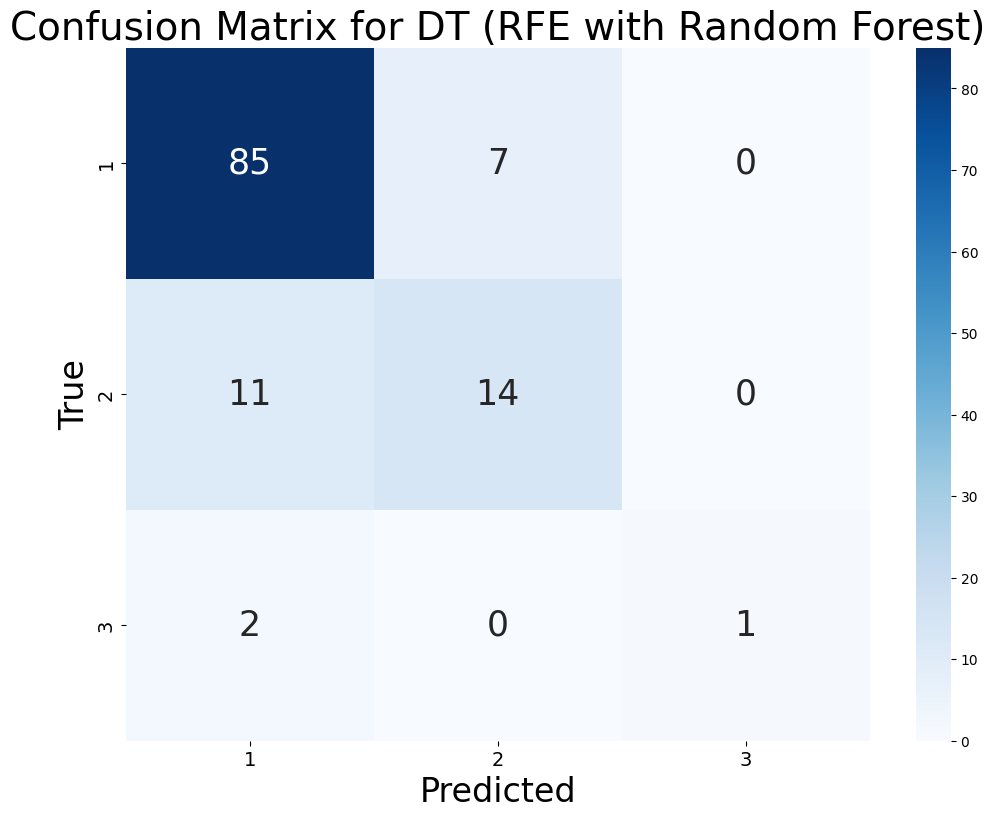

Shape of y_test_bin: (120, 3)


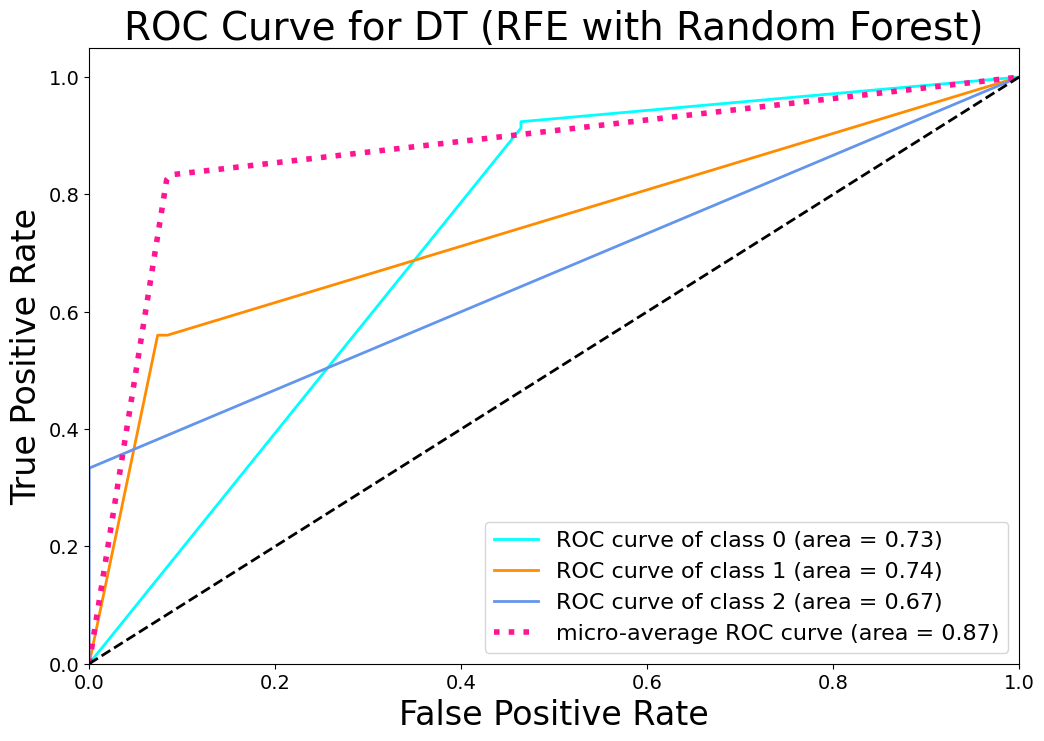

Shape of y_score_rf for LR: (120, 3)
Confusion Matrix for LR (RFE with Random Forest):
[[88  4  0]
 [12 13  0]
 [ 0  0  3]]
              precision    recall  f1-score   support

           1       0.88      0.96      0.92        92
           2       0.76      0.52      0.62        25
           3       1.00      1.00      1.00         3

    accuracy                           0.87       120
   macro avg       0.88      0.83      0.85       120
weighted avg       0.86      0.87      0.86       120



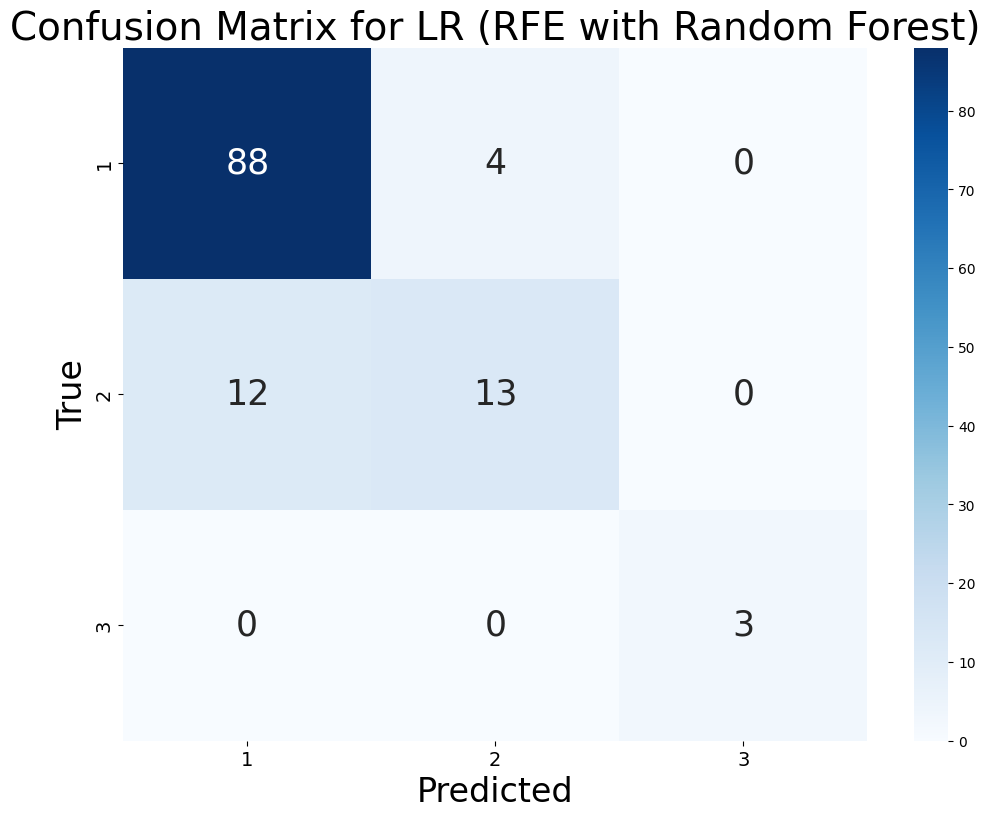

Shape of y_test_bin: (120, 3)


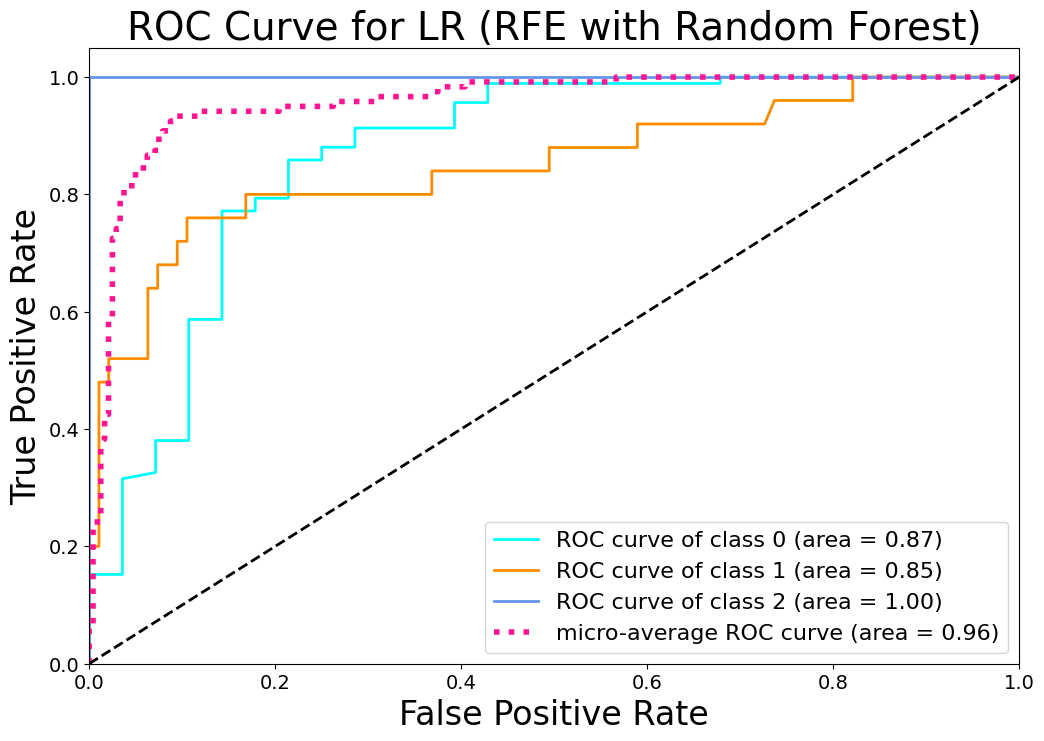

Shape of y_score_rf for RF: (120, 3)
Confusion Matrix for RF (RFE with Random Forest):
[[88  4  0]
 [12 13  0]
 [ 0  0  3]]
              precision    recall  f1-score   support

           1       0.88      0.96      0.92        92
           2       0.76      0.52      0.62        25
           3       1.00      1.00      1.00         3

    accuracy                           0.87       120
   macro avg       0.88      0.83      0.85       120
weighted avg       0.86      0.87      0.86       120



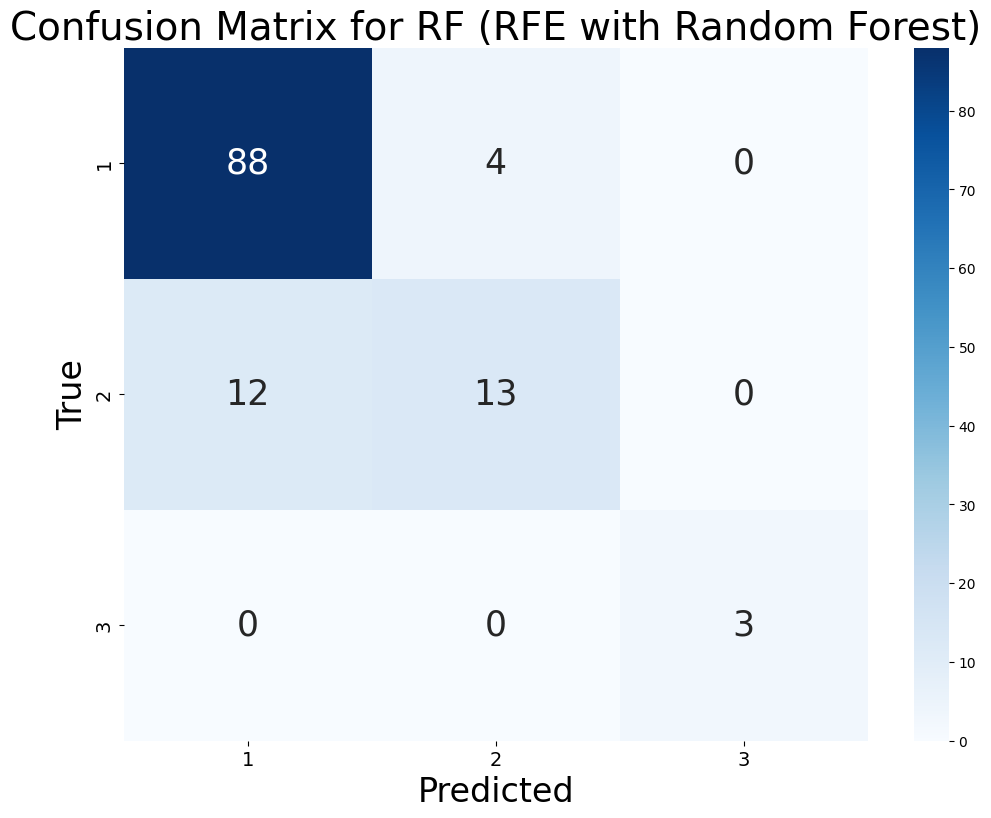

Shape of y_test_bin: (120, 3)


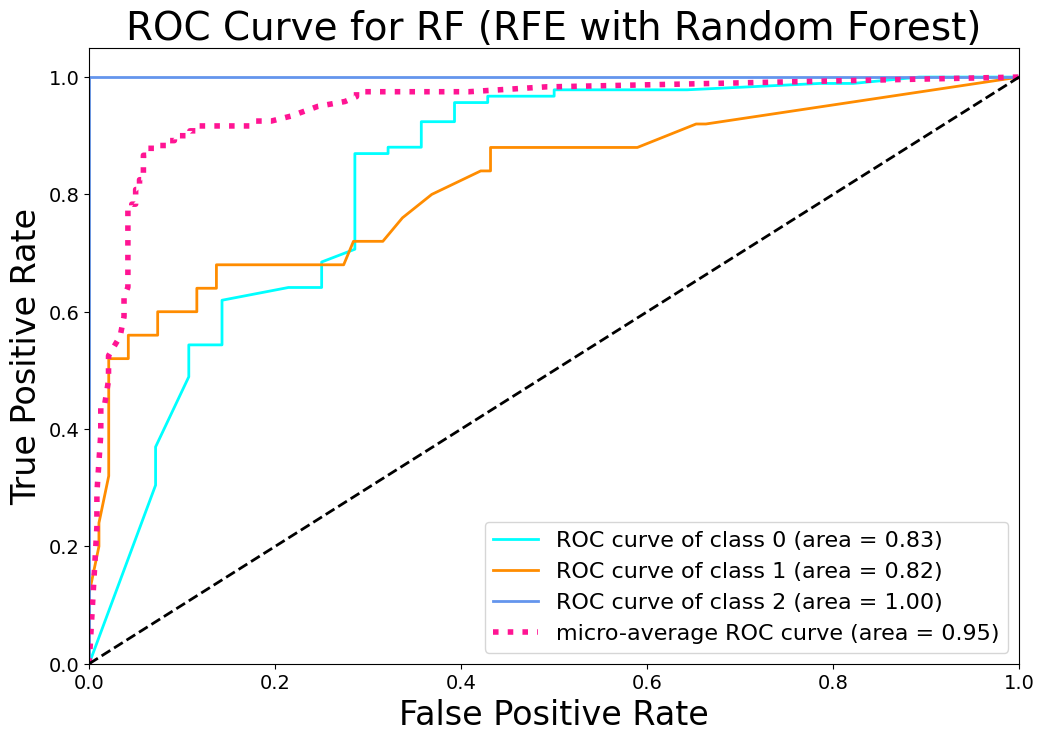

Shape of y_score_rf for SVM: (120, 3)
Confusion Matrix for SVM (RFE with Random Forest):
[[89  3  0]
 [12 13  0]
 [ 1  0  2]]
              precision    recall  f1-score   support

           1       0.87      0.97      0.92        92
           2       0.81      0.52      0.63        25
           3       1.00      0.67      0.80         3

    accuracy                           0.87       120
   macro avg       0.90      0.72      0.78       120
weighted avg       0.86      0.87      0.86       120



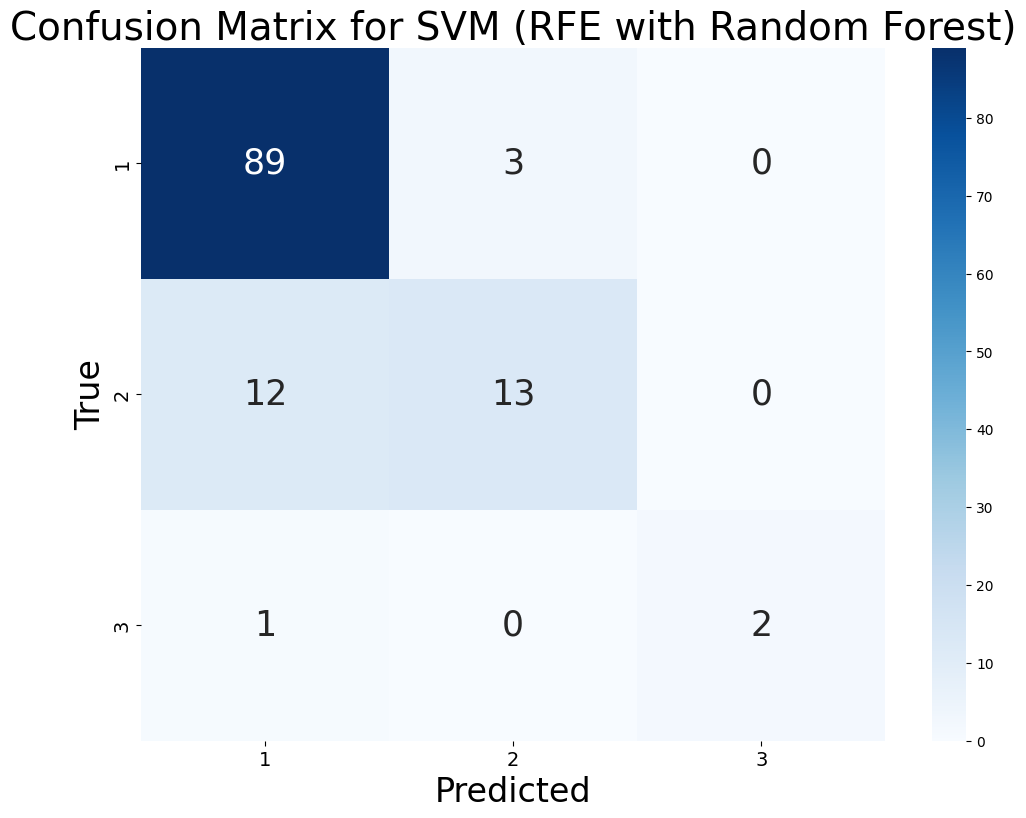

Shape of y_test_bin: (120, 3)


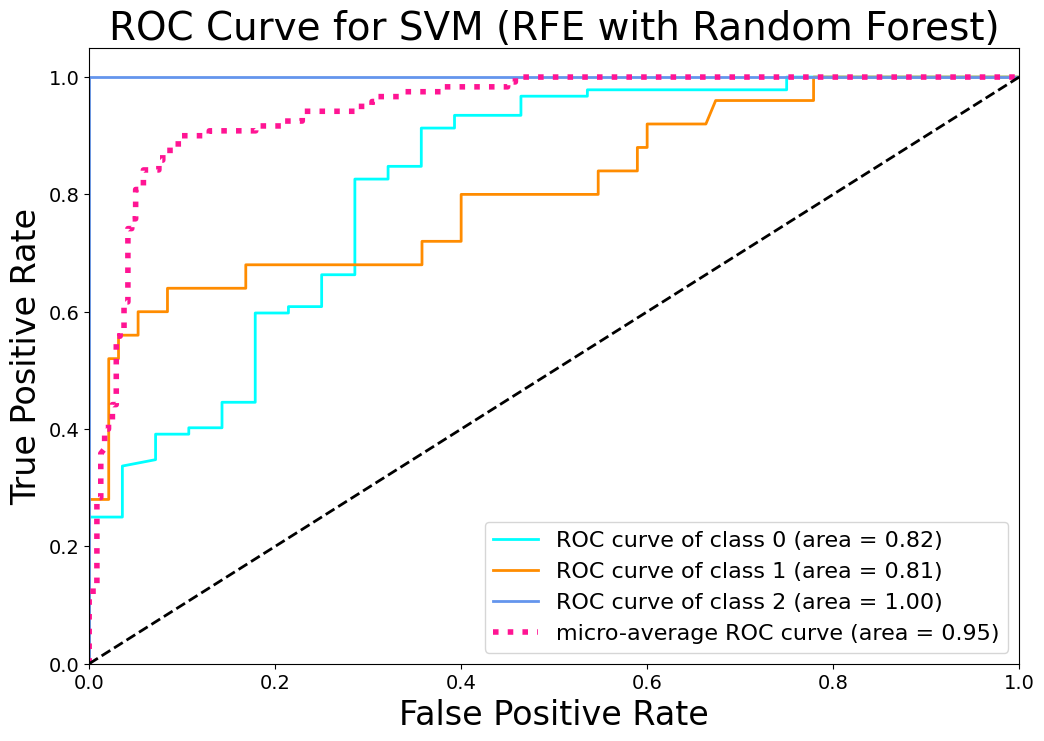

Shape of y_score_rf for NB: (120, 3)
Confusion Matrix for NB (RFE with Random Forest):
[[11 77  4]
 [ 0 25  0]
 [ 0  0  3]]
              precision    recall  f1-score   support

           1       1.00      0.12      0.21        92
           2       0.25      1.00      0.39        25
           3       0.43      1.00      0.60         3

    accuracy                           0.33       120
   macro avg       0.56      0.71      0.40       120
weighted avg       0.83      0.33      0.26       120



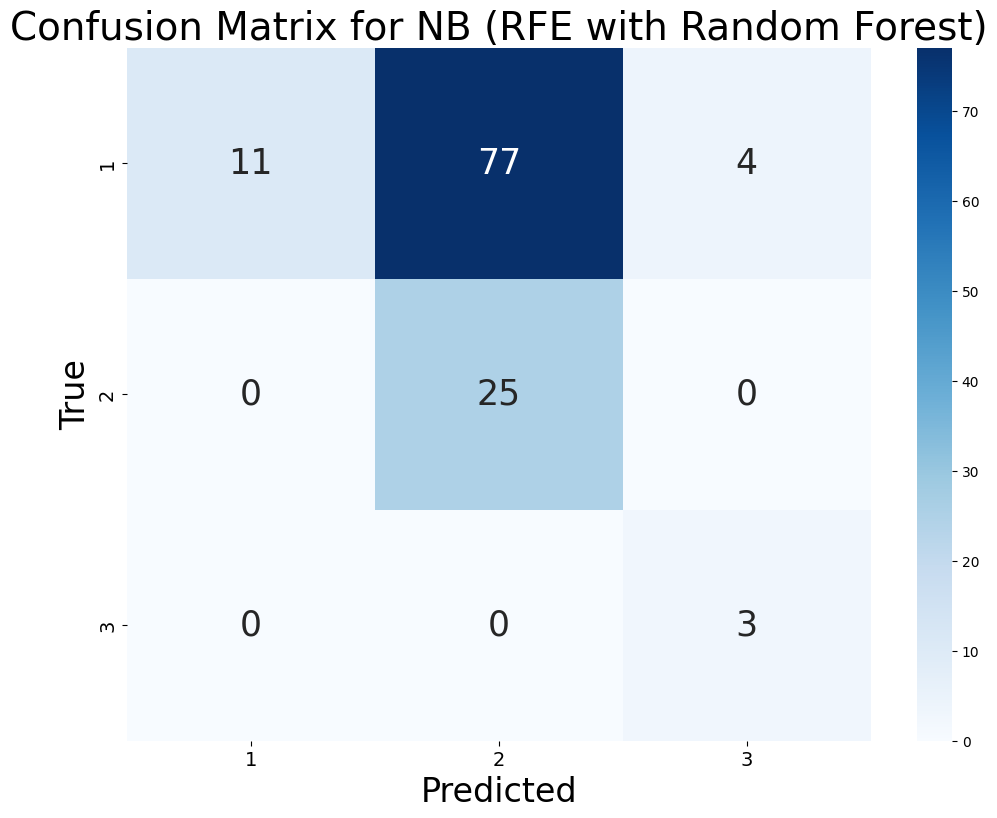

Shape of y_test_bin: (120, 3)


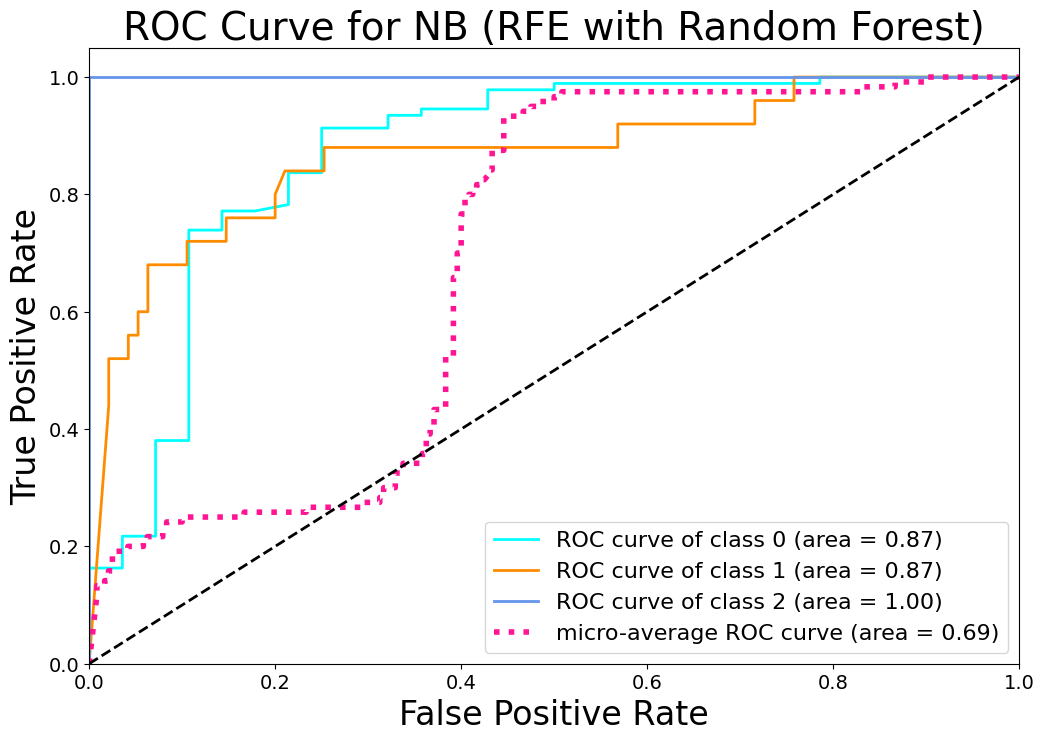

Shape of y_score_rf for KNN: (120, 3)
Confusion Matrix for KNN (RFE with Random Forest):
[[76 16  0]
 [ 8 16  1]
 [ 0  0  3]]
              precision    recall  f1-score   support

           1       0.90      0.83      0.86        92
           2       0.50      0.64      0.56        25
           3       0.75      1.00      0.86         3

    accuracy                           0.79       120
   macro avg       0.72      0.82      0.76       120
weighted avg       0.82      0.79      0.80       120



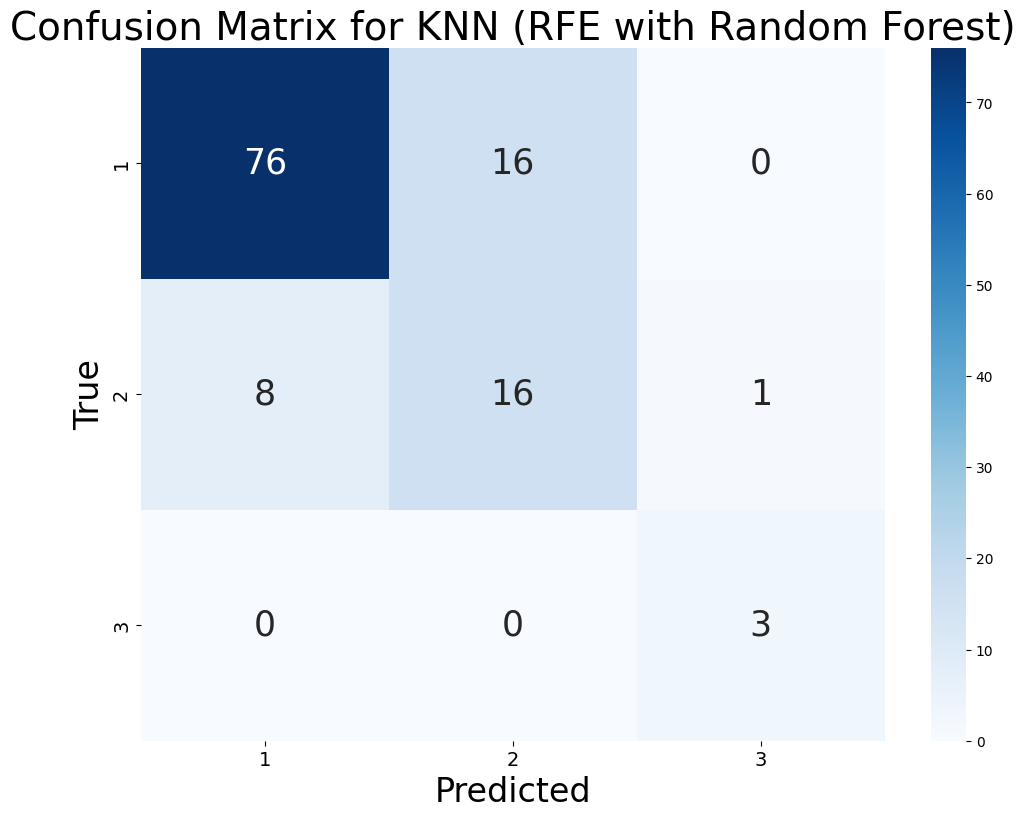

Shape of y_test_bin: (120, 3)


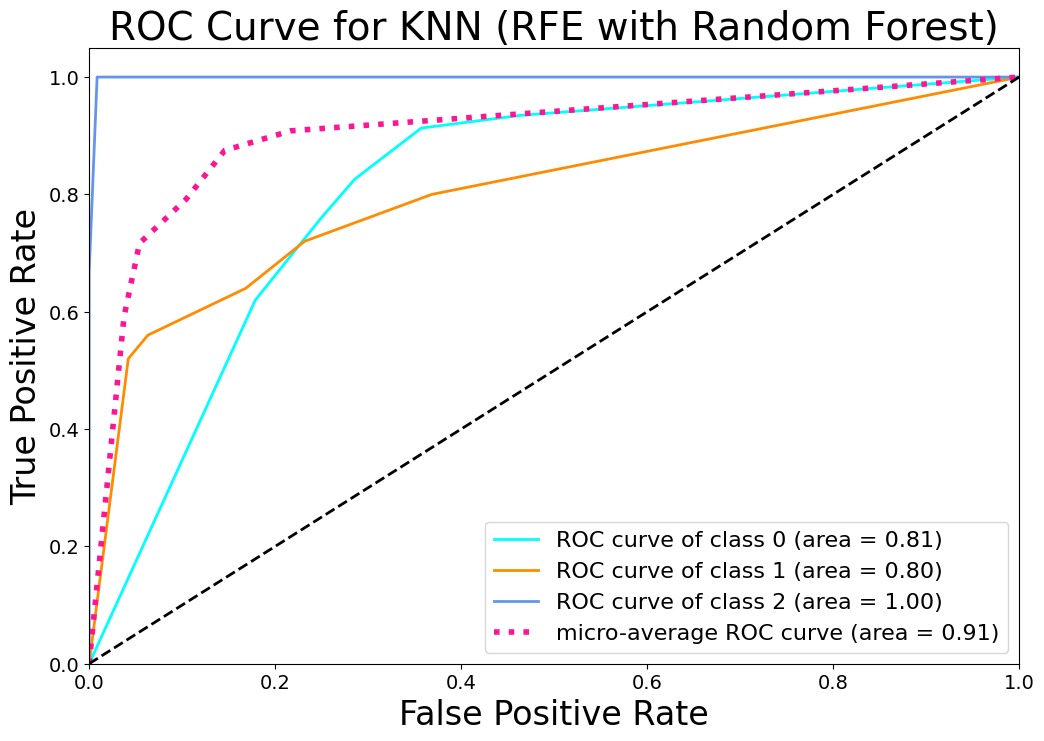

Training and evaluating models with features selected by RFE with Logistic Regression...
Shape of y_score_lr for DT: (120, 3)
Confusion Matrix for DT (RFE with Augmentation):
[[90  2  0]
 [13 12  0]
 [ 2  0  1]]
              precision    recall  f1-score   support

           1       0.86      0.98      0.91        92
           2       0.86      0.48      0.62        25
           3       1.00      0.33      0.50         3

    accuracy                           0.86       120
   macro avg       0.90      0.60      0.68       120
weighted avg       0.86      0.86      0.84       120



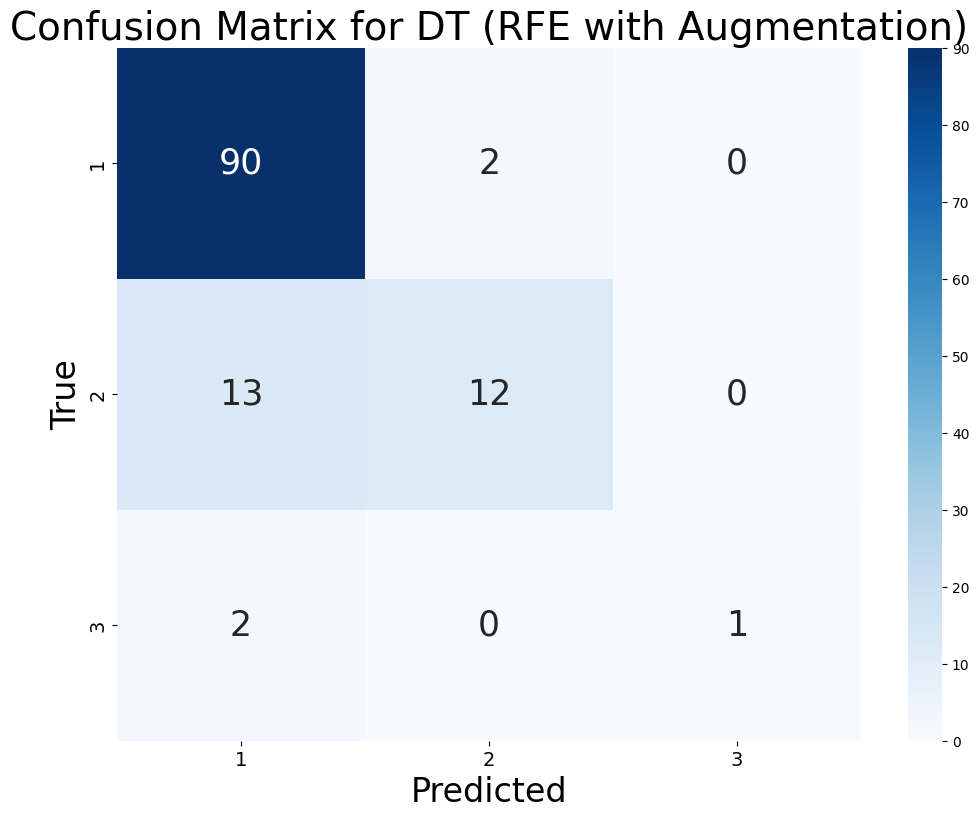

Shape of y_test_bin: (120, 3)


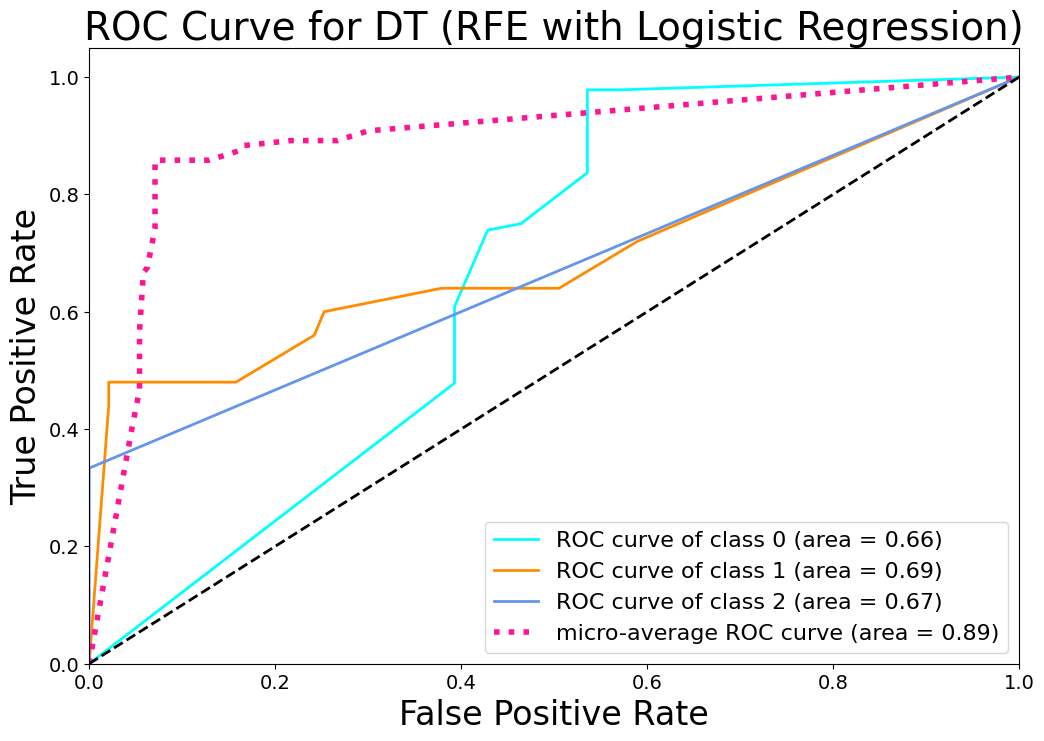

Shape of y_score_lr for LR: (120, 3)
Confusion Matrix for LR (RFE with Augmentation):
[[90  2  0]
 [12 13  0]
 [ 0  0  3]]
              precision    recall  f1-score   support

           1       0.88      0.98      0.93        92
           2       0.87      0.52      0.65        25
           3       1.00      1.00      1.00         3

    accuracy                           0.88       120
   macro avg       0.92      0.83      0.86       120
weighted avg       0.88      0.88      0.87       120



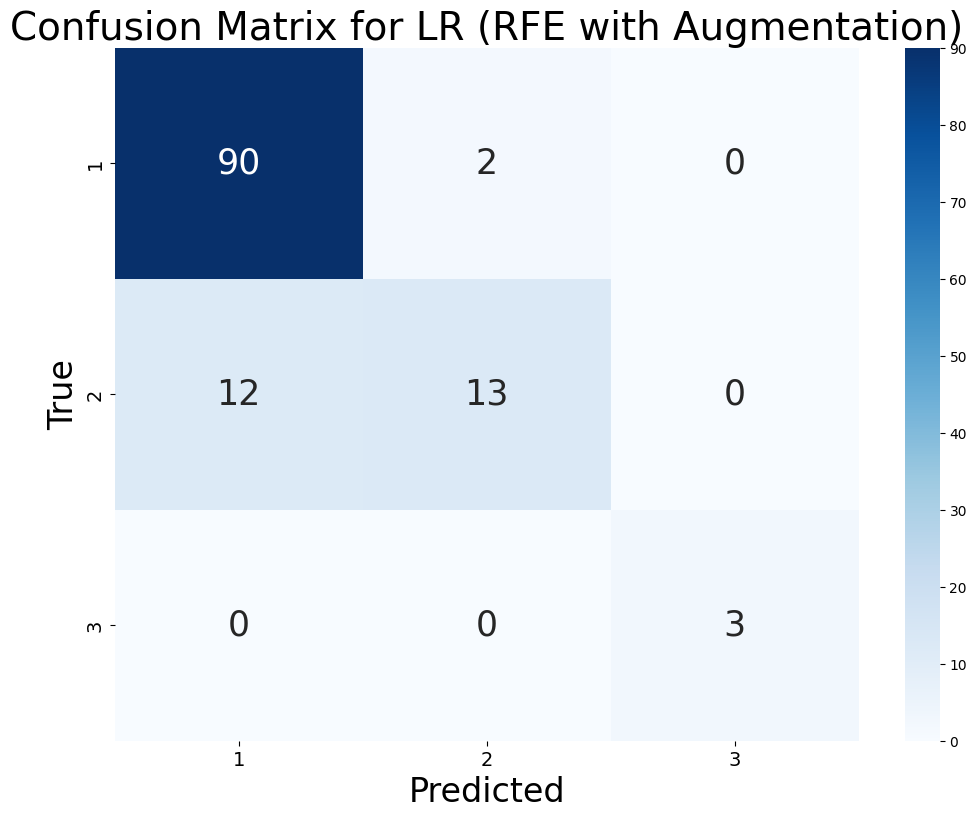

Shape of y_test_bin: (120, 3)


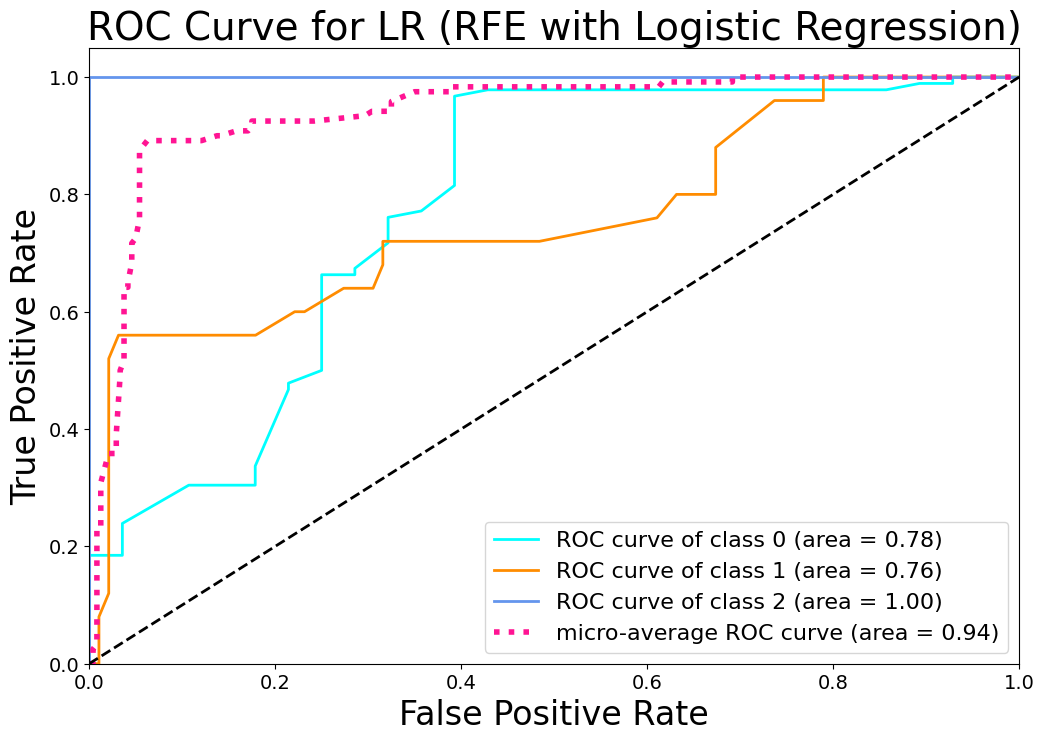

Shape of y_score_lr for RF: (120, 3)
Confusion Matrix for RF (RFE with Augmentation):
[[90  2  0]
 [12 13  0]
 [ 0  0  3]]
              precision    recall  f1-score   support

           1       0.88      0.98      0.93        92
           2       0.87      0.52      0.65        25
           3       1.00      1.00      1.00         3

    accuracy                           0.88       120
   macro avg       0.92      0.83      0.86       120
weighted avg       0.88      0.88      0.87       120



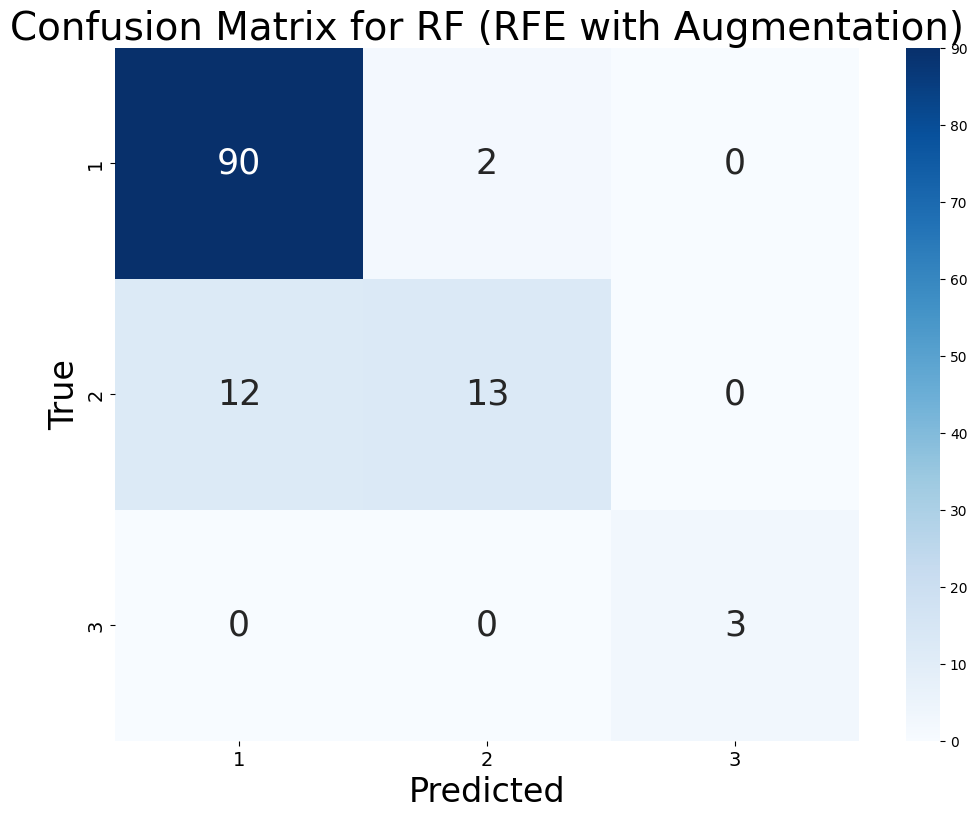

Shape of y_test_bin: (120, 3)


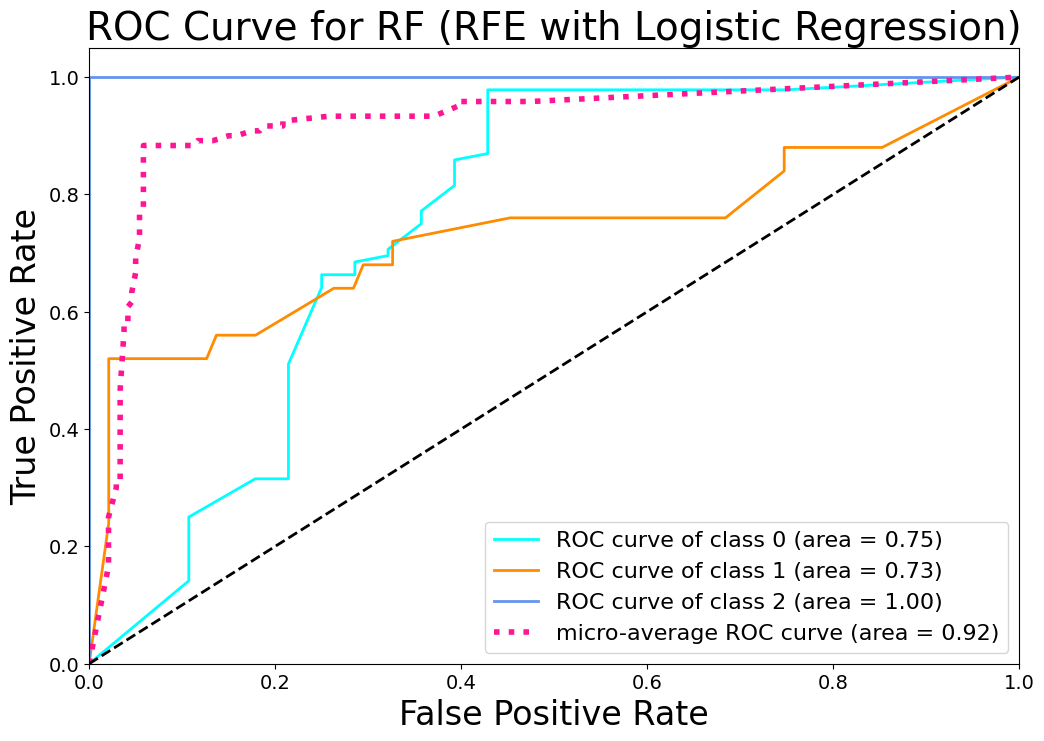

Shape of y_score_lr for SVM: (120, 3)
Confusion Matrix for SVM (RFE with Augmentation):
[[90  2  0]
 [12 13  0]
 [ 0  0  3]]
              precision    recall  f1-score   support

           1       0.88      0.98      0.93        92
           2       0.87      0.52      0.65        25
           3       1.00      1.00      1.00         3

    accuracy                           0.88       120
   macro avg       0.92      0.83      0.86       120
weighted avg       0.88      0.88      0.87       120



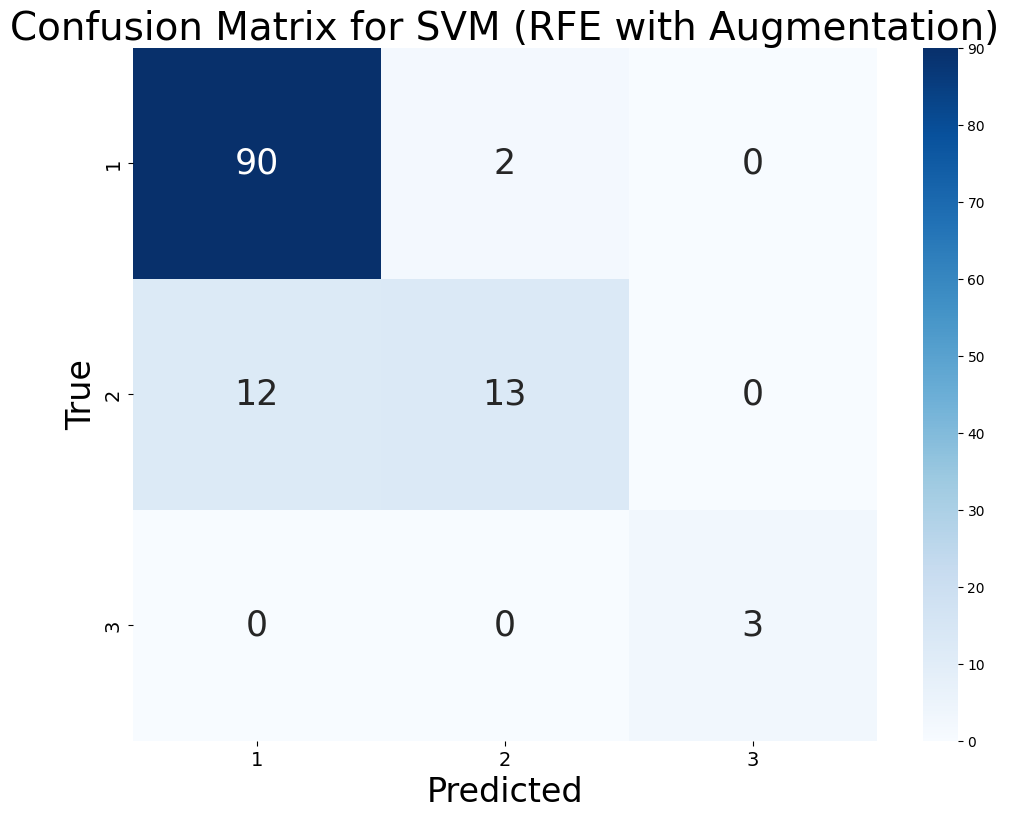

Shape of y_test_bin: (120, 3)


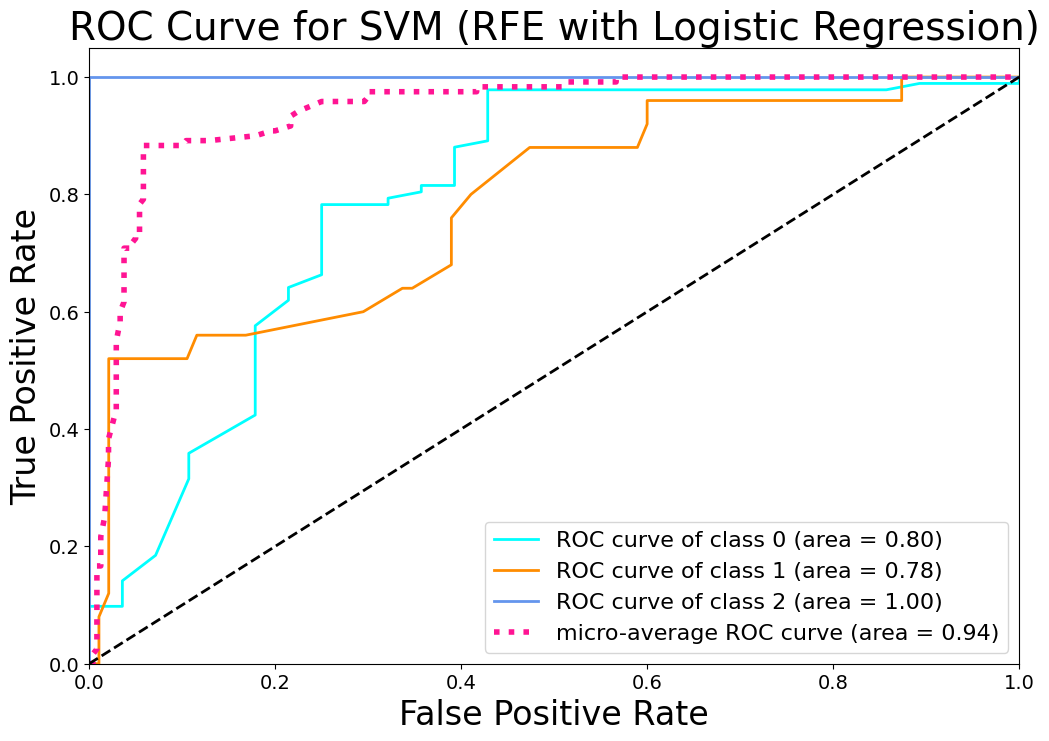

Shape of y_score_lr for NB: (120, 3)
Confusion Matrix for NB (RFE with Augmentation):
[[12  6 74]
 [ 0 13 12]
 [ 0  0  3]]
              precision    recall  f1-score   support

           1       1.00      0.13      0.23        92
           2       0.68      0.52      0.59        25
           3       0.03      1.00      0.07         3

    accuracy                           0.23       120
   macro avg       0.57      0.55      0.30       120
weighted avg       0.91      0.23      0.30       120



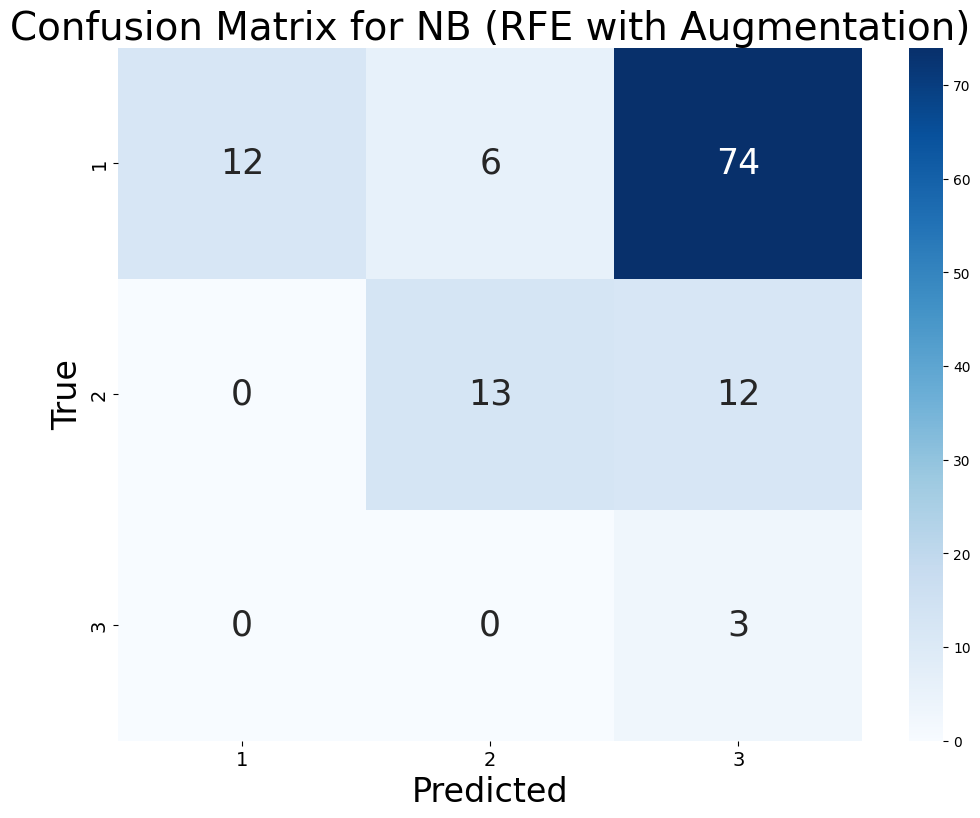

Shape of y_test_bin: (120, 3)


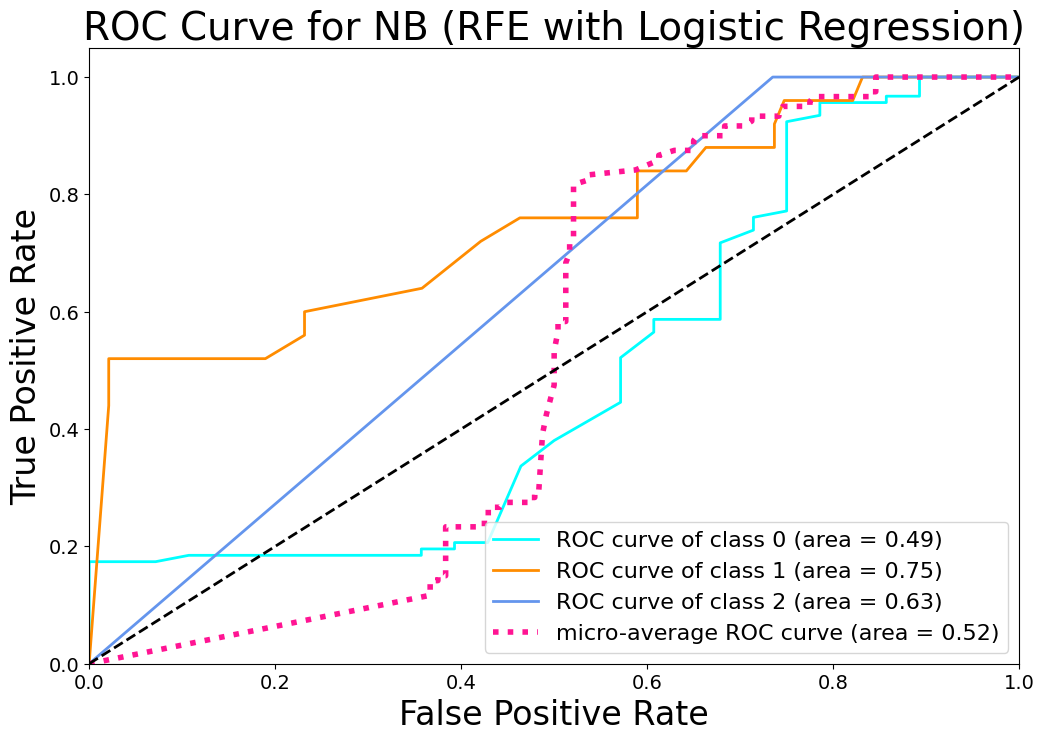

Shape of y_score_lr for KNN: (120, 3)
Confusion Matrix for KNN (RFE with Augmentation):
[[84  8  0]
 [12 13  0]
 [ 0  0  3]]
              precision    recall  f1-score   support

           1       0.88      0.91      0.89        92
           2       0.62      0.52      0.57        25
           3       1.00      1.00      1.00         3

    accuracy                           0.83       120
   macro avg       0.83      0.81      0.82       120
weighted avg       0.82      0.83      0.83       120



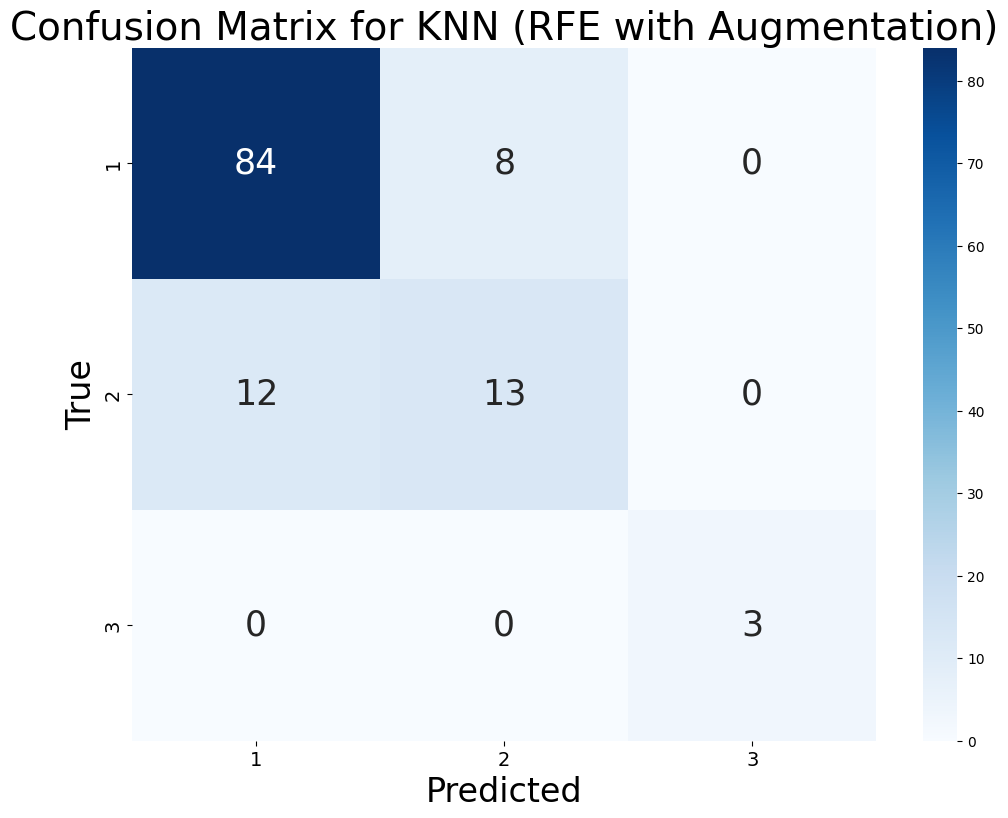

Shape of y_test_bin: (120, 3)


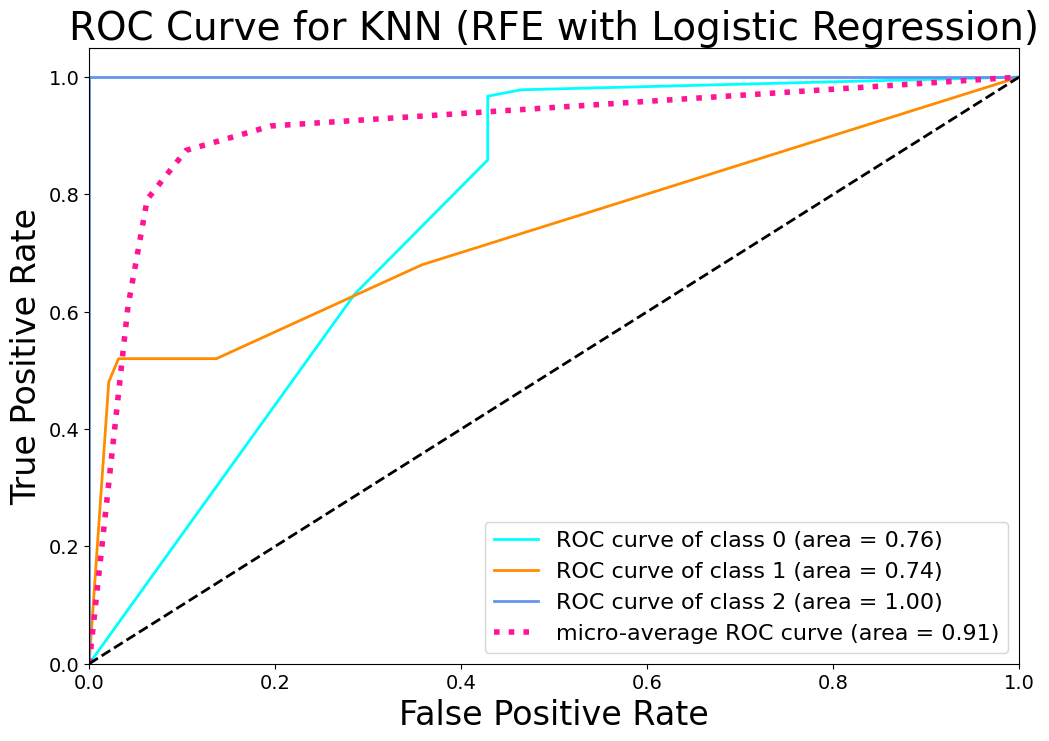

|    | Model   |   Class |   Precision |   Recall |   F1-Score |   Accuracy |
|---:|:--------|--------:|------------:|---------:|-----------:|-----------:|
|  0 | DT      |       1 |        0.87 |     0.92 |       0.89 |       0.83 |
|  1 | DT      |       2 |        0.67 |     0.56 |       0.61 |       0.83 |
|  2 | DT      |       3 |        1.00 |     0.33 |       0.50 |       0.83 |
|  3 | LR      |       1 |        0.88 |     0.96 |       0.92 |       0.87 |
|  4 | LR      |       2 |        0.76 |     0.52 |       0.62 |       0.87 |
|  5 | LR      |       3 |        1.00 |     1.00 |       1.00 |       0.87 |
|  6 | RF      |       1 |        0.88 |     0.96 |       0.92 |       0.87 |
|  7 | RF      |       2 |        0.76 |     0.52 |       0.62 |       0.87 |
|  8 | RF      |       3 |        1.00 |     1.00 |       1.00 |       0.87 |
|  9 | SVM     |       1 |        0.87 |     0.97 |       0.92 |       0.87 |
| 10 | SVM     |       2 |        0.81 |     0.52 |       0.63 |

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from collections import Counter
from itertools import cycle
import pandas as pd
from tabulate import tabulate
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from itertools import cycle
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, LSTM

# Load the processed data
final_df = pd.read_csv('processed_collision_data.csv')

# Filter out instances with crash severity level 0 (NONE)
filtered_df = final_df[final_df['crash_severity'] != 0]

# Identify binary and numerical columns
binary_columns = filtered_df.columns[filtered_df.isin([0, 1]).all()].tolist()
numerical_features = ['Vehicles Involved', 'Number of injuries']

# Create a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features)
    ],
    remainder='passthrough'  # This will leave the binary columns untouched
)

# Fit and transform the data
scaled_data = preprocessor.fit_transform(filtered_df.drop(['Date', 'Time'], axis=1))

# Get the feature names after transformation
scaled_feature_names = (numerical_features + 
                        [col for col in filtered_df.columns if col not in numerical_features + ['Date', 'Time']])

# Convert back to DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=scaled_feature_names, index=filtered_df.index)

# Add back Date and Time columns
scaled_df['Date'] = filtered_df['Date']
scaled_df['Time'] = filtered_df['Time']

print("\nDataFrame after scaling:")
print(scaled_df.head())
print("\nDataFrame shape after scaling:", scaled_df.shape)

# Save processed data
scaled_df.to_csv('Scaled_severity_filtered.csv', index=False)

print("\nProcessed data has been saved to 'Scaled_severity_filtered.csv'")

# Ensure crash_severity is in the dataframe and convert to integers
if 'crash_severity' in scaled_df.columns:
    scaled_df['crash_severity'] = pd.to_numeric(scaled_df['crash_severity'], errors='coerce')
    scaled_df['crash_severity'] = scaled_df['crash_severity'].astype(int)
else:
    print("Error: 'crash_severity' column not found in the dataframe.")
    exit()

# Remove Describe Vehicle Damage columns and Number of injuries from the feature set
features_to_exclude = [col for col in scaled_df.columns if col.startswith('Describe Vehicle Damage_')]
features_to_exclude.append('Number of injuries')

# Separate features and target, excluding specified columns
X = scaled_df.drop(['Date', 'Time', 'crash_severity_label', 'crash_severity'] + features_to_exclude, axis=1)
y = scaled_df['crash_severity']

# Split the data into training and testing sets using stratified sampling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Check the distribution of classes before SMOTE
print("Class distribution before SMOTE:")
print(Counter(y_train))

# Ensure y_train is of integer type
y_train = y_train.astype(int)

# Apply SMOTE to balance only classes 2 and 3 to the target size
smote = SMOTE(sampling_strategy={2: 305, 3: 210}, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Check the distribution of classes after SMOTE
print("\nClass distribution after SMOTE:")
print(Counter(y_train_smote))

# Define and fit RFE with Random Forest
rf_model_rfe = RandomForestClassifier(random_state=42)
rfe_rf = RFE(estimator=rf_model_rfe, n_features_to_select=20)
rfe_rf = rfe_rf.fit(X_train_smote, y_train_smote)
selected_features_rf = [f for f, r in zip(X_train_smote.columns, rfe_rf.ranking_) if r == 1]

# Define and fit RFE with Logistic Regression
logistic_model_rfe = LogisticRegression(random_state=42, max_iter=10000)
rfe_logistic = RFE(estimator=logistic_model_rfe, n_features_to_select=20)
rfe_logistic = rfe_logistic.fit(X_train_smote, y_train_smote)
selected_features_logistic = [f for f, r in zip(X_train_smote.columns, rfe_logistic.ranking_) if r == 1]

# Models to be trained
models = {
    "DT": DecisionTreeClassifier(random_state=42),
    "LR": LogisticRegression(random_state=42, max_iter=10000),
    "RF": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42, probability=True),
    "NB": GaussianNB(),
    "KNN": KNeighborsClassifier()
}

# Initialize a list to store the results
results_rf = []
results_lr = []

print("Training and evaluating models with features selected by RFE with Random Forest...")
for name, model in models.items():
    X_train_selected_rf = X_train_smote[selected_features_rf]
    X_test_selected_rf = X_test[selected_features_rf]
    model.fit(X_train_selected_rf, y_train_smote)
    y_pred_rf = model.predict(X_test_selected_rf)
    
    if name == "Support Vector Machine":
        y_score_rf = model.decision_function(X_test_selected_rf)
        if y_score_rf.ndim == 1:  # binary classification
            y_score_rf = np.column_stack((1-y_score_rf, y_score_rf))
        else:  # multi-class
            y_score_rf = y_score_rf.reshape(X_test_selected_rf.shape[0], -1)
    else:
        y_score_rf = model.predict_proba(X_test_selected_rf)

    print(f"Shape of y_score_rf for {name}:", y_score_rf.shape)

    print(f"Confusion Matrix for {name} (RFE with Random Forest):")
    print(confusion_matrix(y_test, y_pred_rf))
    report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
    print(classification_report(y_test, y_pred_rf))

    # Collecting the metrics
    for label in report_rf.keys():
        if label in ['accuracy', 'macro avg', 'weighted avg']:
            continue
        results_rf.append({
            'Model': name,
            'Class': label,
            'Precision': report_rf[label]['precision'],
            'Recall': report_rf[label]['recall'],
            'F1-Score': report_rf[label]['f1-score'],
            'Accuracy': report_rf['accuracy']
        })

    # Generate the confusion matrix heatmap
    cm_lr = confusion_matrix(y_test, y_pred_rf)
    plt.figure(figsize=(12, 9))  # Increased figure size for better visibility
    sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_,
                annot_kws={"size": 25})  # Increased annotation font size
    plt.xlabel('Predicted', fontsize=24)  # Increased x-label font size
    plt.ylabel('True', fontsize=24)  # Increased y-label font size
    plt.title(f'Confusion Matrix for {name} (RFE with Random Forest)', fontsize=28)  # Increased title font size
    plt.xticks(fontsize=14)  # Increased x-axis tick label font size
    plt.yticks(fontsize=14)  # Increased y-axis tick label font size
    plt.show()

    # Binarize the output
    y_test_bin = label_binarize(y_test, classes=np.unique(y_train_smote))
    print(f"Shape of y_test_bin:", y_test_bin.shape)
    n_classes = y_test_bin.shape[1]

    # Plot ROC curve
    fpr_rf = dict()
    tpr_rf = dict()
    roc_auc_rf = dict()
    for i in range(n_classes):
        fpr_rf[i], tpr_rf[i], _ = roc_curve(y_test_bin[:, i], y_score_rf[:, i])
        roc_auc_rf[i] = auc(fpr_rf[i], tpr_rf[i])
    fpr_rf["micro"], tpr_rf["micro"], _ = roc_curve(y_test_bin.ravel(), y_score_rf.ravel())
    roc_auc_rf["micro"] = auc(fpr_rf["micro"], tpr_rf["micro"])

    plt.figure(figsize=(12, 8))
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red'])
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr_rf[i], tpr_rf[i], color=color, lw=2, label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc_rf[i]))
    plt.plot(fpr_rf["micro"], tpr_rf["micro"], color='deeppink', linestyle=':', linewidth=4, label='micro-average ROC curve (area = {0:0.2f})'.format(roc_auc_rf["micro"]))
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=24)
    plt.ylabel('True Positive Rate', fontsize=24)
    plt.title(f'ROC Curve for {name} (RFE with Random Forest)', fontsize=28)
    plt.xticks(fontsize=14)  # Increased x-axis tick label font size
    plt.yticks(fontsize=14)
    plt.legend(loc="lower right", prop={'size': 16})
    plt.show()

print("Training and evaluating models with features selected by RFE with Logistic Regression...")
for name, model in models.items():
    X_train_selected_lr = X_train_smote[selected_features_logistic]
    X_test_selected_lr = X_test[selected_features_logistic]
    model.fit(X_train_selected_lr, y_train_smote)
    y_pred_lr = model.predict(X_test_selected_lr)
    
    if name == "Support Vector Machine":
        y_score_lr = model.decision_function(X_test_selected_lr)
        if y_score_lr.ndim == 1:  # binary classification
            y_score_lr = np.column_stack((1-y_score_lr, y_score_lr))
        else:  # multi-class
            y_score_lr = y_score_lr.reshape(X_test_selected_lr.shape[0], -1)
    else:
        y_score_lr = model.predict_proba(X_test_selected_lr)

    print(f"Shape of y_score_lr for {name}:", y_score_lr.shape)

    print(f"Confusion Matrix for {name} (RFE with Augmentation):")
    print(confusion_matrix(y_test, y_pred_lr))
    report_lr = classification_report(y_test, y_pred_lr, output_dict=True)
    print(classification_report(y_test, y_pred_lr))

    # Collecting the metrics
    for label in report_lr.keys():
        if label in ['accuracy', 'macro avg', 'weighted avg']:
            continue
        results_lr.append({
            'Model': name,
            'Class': label,
            'Precision': report_lr[label]['precision'],
            'Recall': report_lr[label]['recall'],
            'F1-Score': report_lr[label]['f1-score'],
            'Accuracy': report_lr['accuracy']
        })

    # Generate the confusion matrix heatmap
    cm_lr = confusion_matrix(y_test, y_pred_lr)
    plt.figure(figsize=(12, 9))  # Increased figure size for better visibility
    sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_,
                annot_kws={"size": 25})  # Increased annotation font size
    plt.xlabel('Predicted', fontsize=24)  # Increased x-label font size
    plt.ylabel('True', fontsize=24)  # Increased y-label font size
    plt.title(f'Confusion Matrix for {name} (RFE with Augmentation)', fontsize=28)  # Increased title font size
    plt.xticks(fontsize=14)  # Increased x-axis tick label font size
    plt.yticks(fontsize=14)  # Increased y-axis tick label font size
    plt.show()
    # Binarize the output
    y_test_bin = label_binarize(y_test, classes=np.unique(y_train_smote))
    print(f"Shape of y_test_bin:", y_test_bin.shape)
    n_classes = y_test_bin.shape[1]

    # Plot ROC curve
    fpr_lr = dict()
    tpr_lr = dict()
    roc_auc_lr = dict()
    for i in range(n_classes):
        fpr_lr[i], tpr_lr[i], _ = roc_curve(y_test_bin[:, i], y_score_lr[:, i])
        roc_auc_lr[i] = auc(fpr_lr[i], tpr_lr[i])
    fpr_lr["micro"], tpr_lr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score_lr.ravel())
    roc_auc_lr["micro"] = auc(fpr_lr["micro"], tpr_lr["micro"])

    plt.figure(figsize=(12, 8))
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red'])
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr_lr[i], tpr_lr[i], color=color, lw=2, 
                 label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc_lr[i]))
    plt.plot(fpr_lr["micro"], tpr_lr["micro"], color='deeppink', linestyle=':', linewidth=4, 
             label='micro-average ROC curve (area = {0:0.2f})'.format(roc_auc_lr["micro"]))
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=24)
    plt.ylabel('True Positive Rate', fontsize=24)
    plt.title(f'ROC Curve for {name} (RFE with Logistic Regression)', fontsize=28)
    plt.xticks(fontsize=14)  # Increased x-axis tick label font size
    plt.yticks(fontsize=14)
    plt.legend(loc="lower right", prop={'size': 16})
    plt.show()

# Convert results to DataFrame
results_df_rf = pd.DataFrame(results_rf)
results_df_lr = pd.DataFrame(results_lr)

# Print the results in a tabulated format
print(tabulate(results_df_rf, headers='keys', tablefmt='pipe', floatfmt='.2f'))

# Print the results in a tabulated format
print(tabulate(results_df_lr, headers='keys', tablefmt='pipe', floatfmt='.2f'))


In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Number of folds for cross-validation
n_folds = 10

print("\nPerforming 10-fold cross-validation...")

# For Random Forest selected features
print("\nCross-validation with features selected by Random Forest RFE:")
for name, model in models.items():
    X_selected_rf = X[selected_features_rf]
    
    # Create a StratifiedKFold object
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    # Perform cross-validation
    cv_scores = cross_val_score(model, X_selected_rf, y, cv=skf, scoring='accuracy')
    
    print(f"{name}:")
    print(f"Cross-validation scores: {cv_scores}")
    print(f"Mean CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# For Logistic Regression selected features
print("\nCross-validation with features selected by Logistic Regression RFE:")
for name, model in models.items():
    X_selected_lr = X[selected_features_logistic]
    
    # Create a StratifiedKFold object
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    # Perform cross-validation
    cv_scores = cross_val_score(model, X_selected_lr, y, cv=skf, scoring='accuracy')
    
    print(f"{name}:")
    print(f"Cross-validation scores: {cv_scores}")
    print(f"Mean CV score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")